# Fast Reading of the Moody Chart

The Moody chart links Reynolds number, relative roughness, and the Darcy friction factor. Moody popularized it as a pipe-flow calculation tool, and this example uses Haaland's explicit correlation to automate the reading {cite:p}`moody1944friction_factors,haaland1983friction_factor`.

The laminar region uses:

$$
f=\frac{64}{Re}
$$

The turbulent region is approximated with Haaland's explicit equation:

$$
\frac{1}{\sqrt{f}} \approx -1.8\log_{10}\left[\left(\frac{\varepsilon/D}{3.7}\right)^{1.11}+\frac{6.9}{Re}\right]
$$

```{admonition} What to modify
:class: dropdown
Change `roughness_values` or add new design points in `points`. The logarithmic scale makes laminar flow, transition, and turbulence visible at the same time.
```


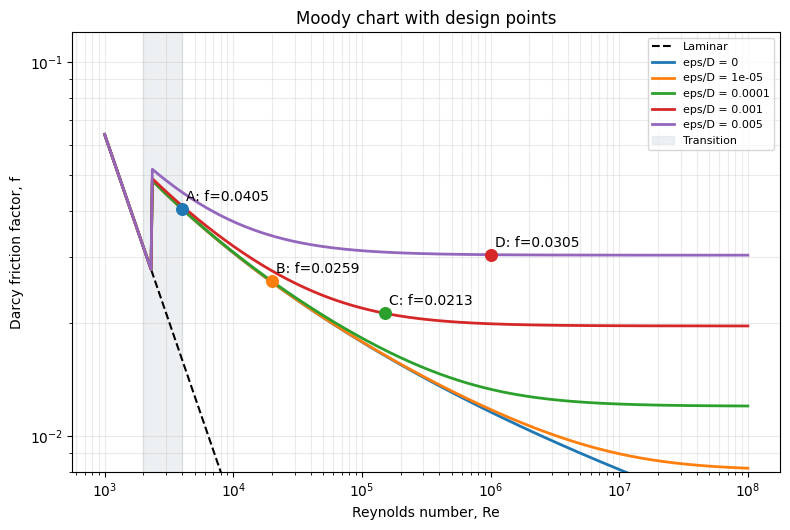

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def friction_factor(Re, eps_rel):
    Re = np.asarray(Re, dtype=float)
    f = np.empty_like(Re)
    laminar = Re < 2300
    f[laminar] = 64 / Re[laminar]
    turbulent = ~laminar
    # Haaland equation for turbulent flow.
    f[turbulent] = (-1.8 * np.log10((eps_rel / 3.7)**1.11 + 6.9 / Re[turbulent]))**-2
    return f

Re = np.logspace(3, 8, 500)
roughness_values = [0.0, 1e-5, 1e-4, 1e-3, 5e-3]
points = [
    (4.0e3, 1e-4, "A"),
    (2.0e4, 1e-4, "B"),
    (1.5e5, 1e-3, "C"),
    (1.0e6, 5e-3, "D"),
]

plt.figure(figsize=(8, 5.4))
plt.loglog(Re, 64/Re, "k--", linewidth=1.5, label="Laminar")
for eps in roughness_values:
    plt.loglog(Re, friction_factor(Re, eps), linewidth=2, label=f"eps/D = {eps:g}")

for Re_p, eps_p, name in points:
    f_p = friction_factor(np.array([Re_p]), eps_p)[0]
    plt.scatter(Re_p, f_p, s=70, zorder=5)
    plt.text(Re_p * 1.08, f_p * 1.05, f"{name}: f={f_p:.4f}")

plt.axvspan(2000, 4000, color="#d8dee4", alpha=0.45, label="Transition")
plt.xlabel("Reynolds number, Re")
plt.ylabel("Darcy friction factor, f")
plt.title("Moody chart with design points")
plt.grid(True, which="both", alpha=0.25)
plt.ylim(0.008, 0.12)
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Interpretation

In laminar flow the friction factor depends only on Reynolds number. In turbulent flow, relative roughness shifts the curves and can dominate the behavior at high Reynolds numbers.

```{admonition} Guided reading
:class: dropdown
Compare points B and C. Both are turbulent, but C has a higher relative roughness and therefore lies on a higher friction curve.
```
